# Differentiable acausal DAEs: learning unmodeled drag inside a constrained pendulum

A swinging pendulum on a rigid link is one of the oldest test cases in mechanics, and one of the most awkward to *simulate correctly*: the rigid link is a holonomic constraint $x^2 + y^2 = L^2$ that turns Newton's second law into an **index-3 differential-algebraic equation** (DAE), not an ODE. Jaxonomy compiles such acausal models through Pantelides index reduction. In this tutorial we take a real pendulum whose *aerodynamic drag the modeler never wrote down*, bolt a small neural network onto the compiled DAE's differential rows as a learned correction, and fit its weights by gradient descent **through the BDF-DAE adjoint** — `jax.grad` flows from a terminal-state loss all the way into the network's parameters.

After reading this you will be able to: (1) reason about why a rigid constraint makes the pendulum a high-index DAE and what index reduction does to it; (2) attach a `NeuralDAEBlock` to an acausal diagram so the learned term lands on the right differential row without entering the symbolic pipeline; (3) train that term against terminal-state data with autodiff through `jaxonomy.simulate`; and (4) read off where the learned correction is — and is not — identifiable.

> **Estimated reading time:** ~30 min. **Runtime on CPU:** ~4–5 min end-to-end (the fit is ~20–30 grad steps at ~7 s/step; everything else is seconds). This is an *advanced* example — it assumes you have met the UDE and conservation-law notebooks below.

## The moat: differentiable acausal modeling

This notebook sits at the intersection of three capabilities that, to our knowledge, no single tool combines:

- **Acausal (equation-based) modeling with index reduction.** You write the *physics as equations* — including the implicit constraint $x^2+y^2=L^2$ — and the compiler figures out the causality and reduces the DAE index. Modelica/Dymola do this; most ML-for-dynamics tools do not.
- **Learned terms inside the dynamics.** A neural network supplies a missing physical effect (here, drag). Universal Differential Equation (UDE) frameworks like [Neuromancer](https://github.com/pnnl/neuromancer) and SciML's `DiffEqFlux` do this — for *causal* ODEs you write in explicit state-space form.
- **End-to-end automatic differentiation through the solver.** `jax.grad` flows from a loss, through the implicit BDF integration of the constrained DAE, into the network weights. Modelica has no autodiff; causal UDE tools have no Pantelides index reduction.

Putting all three together is the wedge. Modelica can express the constraint but can't differentiate through it. Causal-function-first ML tools can differentiate but can't express the constraint coupling (try writing $x^2+y^2=L^2$ as an explicit `dx/dt = f(x)` — you can't, the link force is an algebraic unknown). The `NeuralDAEBlock` lets you have the symbolic constraint structure *and* a differentiable learned correction in the same model.

This notebook is a sibling to two others you should read first for context and house style:

- [Universal Differential Equations and symbolic regression](ude_and_sr_lotka_volterra.ipynb) — the *causal-ODE* version of "learn the missing term," on Lotka–Volterra. We borrow its ravel-the-MLP-into-a-flat-`theta` pattern.
- [Conservation laws as CI](conservation_laws_as_ci.ipynb) — the property-test framework. We reuse its discipline for the energy / constraint-residual validation in section 9.

## Prerequisites

- **Acausal modeling in Jaxonomy.** You should know what `EqnEnv`, `AcausalDiagram`, and `AcausalCompiler` are. See the [acausal module docstring](https://github.com/machinavitalis/jaxonomy/blob/main/jaxonomy/acausal/__init__.py) and the LC-oscillator section of [Conservation laws as CI](conservation_laws_as_ci.ipynb).
- **Autodiff through `simulate`.** The [UDE notebook](ude_and_sr_lotka_volterra.ipynb) and [PID tuning](pid_tuning.ipynb) cover `SimulatorOptions(enable_autodiff=True)` and `jax.grad` of a simulation cost.
- **DAEs and index.** A passing familiarity with "index of a DAE" helps; we re-derive what we need.

> **Note:** This notebook requires the phase-2 `NeuralDAEBlock` API. A clean `import jaxonomy` is all you need once you are on a version that ships it (the import cell below is exactly what an end user writes).

## 1. Imports and conventions

We set the random seed once, silence the simulator's per-run INFO banner, and import only what later cells use. The acausal pieces (`AcausalCompiler`, `AcausalDiagram`, `EqnEnv`, `NeuralDAEBlock`) come straight off `jaxonomy.acausal`; `PlanarPendulum` lives in the planar component library.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax.flatten_util import ravel_pytree
import optax

import jaxonomy
from jaxonomy import SimulatorOptions, logging
from jaxonomy.acausal import AcausalCompiler, AcausalDiagram, EqnEnv, NeuralDAEBlock
from jaxonomy.acausal.component_library.planar import PlanarPendulum

logging.set_log_level(logging.ERROR)  # quiet the per-simulate INFO banner

SEED = 0
np.random.seed(SEED)

## 2. The motivating problem

Picture a pendulum on a test rig: a point mass $m$ on a rigid massless link of length $L$, anchored at the origin, released from rest at $30^\circ$ below horizontal. We have a clean first-principles model of it — gravity plus the rigid link. But when we compare our model to the rig, the swing *decays*: the real bob loses amplitude every period. The link is rigid (no spring loss) and we modeled the pivot as frictionless, so the missing energy sink is **aerodynamic drag** on the bob — a term the modeler simply didn't write, because drag coefficients are annoying to measure and the modeler hoped it was negligible.

It is not negligible, and worse, drag on a bluff body is *quadratic* in speed, $F_\text{drag} = -c\,v\,|v|$, not the linear $-cv$ a lazy first guess would assume. We want to recover this missing effect from data — without re-deriving the whole model — by letting a small neural network learn the correction and fitting it through the simulator.

We define the "real rig" synthetically (so we have ground truth to validate against): it is the same constrained pendulum *plus* a known quadratic drag. Our "model" is the constrained pendulum *plus a neural network of unknown form*. The learning task is to make the model match the rig.

## 3. Mathematical model

### 3.1 Symbols

| Symbol | Meaning | Units |
|---|---|---|
| $\mathbf{r} = (x, y)$ | bob position (Cartesian, origin at pivot) | m |
| $\mathbf{v} = (v_x, v_y)$ | bob velocity | m s$^{-1}$ |
| $\mathbf{a} = (a_x, a_y)$ | bob acceleration | m s$^{-2}$ |
| $\lambda$ | Lagrange multiplier (link tension / length) | N m$^{-2}$ |
| $m$ | bob mass | kg |
| $L$ | link length | m |
| $\mathbf{g} = (0, -g)$ | gravitational acceleration, $g = 9.81$ | m s$^{-2}$ |
| $c$ | true drag coefficient | kg m$^{-1}$ |
| $\theta$ | (overloaded) neural-network parameter vector | — |
| $f_{NN}(\mathbf{v}; \boldsymbol\theta)$ | learned correction on a differential row | m s$^{-2}$ |

> **Note:** $\theta$ does double duty in the pendulum literature (release angle) and in ML (parameters). We use $\theta_0$ for the *release angle* and $\boldsymbol\theta$ (bold) for the *network parameters*; the context never ambiguous from here on.

### 3.2 Constrained Newtonian dynamics

Newton's second law for the bob, with the link modeled by a constraint force along $\mathbf{r}$, plus the holonomic constraint:

$$
\dot{\mathbf r} = \mathbf v, \qquad
m\,\dot{\mathbf v} = -2\lambda\,\mathbf r + m\,\mathbf g, \qquad
0 = x^2 + y^2 - L^2.
\tag{1}
$$

The constraint force $-2\lambda\mathbf r$ points along the link (the gradient of $x^2+y^2$), and $\lambda$ is whatever value keeps the bob on the circle. Counting: we have four differential states $(x,y,v_x,v_y)$ and one algebraic unknown $\lambda$, with five differential equations and one algebraic equation — a DAE.

**Dimensional check on $\lambda$.** The term $2\lambda x$ must be a force, $[\text{N}] = [\text{kg}\,\text{m}\,\text{s}^{-2}]$. Since $[x] = \text{m}$, we need $[\lambda] = \text{kg}\,\text{s}^{-2} = \text{N}\,\text{m}^{-1}$... but the standard form writes it as $\text{N}\,\text{m}^{-2}$ when $\lambda$ multiplies the *unit-normalized* constraint gradient. Either way the constraint force comes out in newtons — good. The exact bookkeeping is the component's, not ours; what matters is that $\lambda$ is algebraic.

### 3.3 Why this is a high-index DAE

The constraint $g(\mathbf r) = x^2+y^2-L^2 = 0$ contains *no* derivative of $\lambda$ — $\lambda$ does not appear in it at all. To find an equation that determines $\lambda$, we must differentiate the constraint with respect to time:

$$
\frac{d}{dt}(x^2+y^2-L^2) = 2x v_x + 2 y v_y = 0 \quad\text{(velocity-level constraint)},
\tag{2}
$$

still no $\lambda$. Differentiate again:

$$
2(v_x^2 + v_y^2) + 2(x a_x + y a_y) = 0 \quad\text{(acceleration-level constraint)}.
\tag{3}
$$

Now substitute $a_x, a_y$ from $(1)$ — and $\lambda$ finally appears. We had to differentiate the algebraic equation **twice** before the algebraic unknown surfaced; in DAE terminology the system has **(differentiation) index 2** in the semi-explicit form, or **index 3** counted on the original second-order equations. This is the precise sense in which a rigid constraint is "harder than an ODE": you cannot integrate $(1)$ as written, because the mass matrix is singular on the constraint row and naive integration drifts off the circle.

**Limiting-case intuition.** If you *removed* the constraint (let $L\to\infty$, a free bob), $\lambda=0$ and $(1)$ collapses to a plain ODE $\dot{\mathbf v}=\mathbf g$ — projectile motion, index 0. The index is a measure of *how tightly the constraint couples the unknowns*; the rigid link is maximally tight.

### 3.4 What index reduction produces, and where the neural term goes

Jaxonomy's `AcausalCompiler` runs the **Pantelides algorithm** (Pantelides 1988) to discover exactly the differentiations $(2)$–$(3)$ symbolically, then **dummy-derivative substitution** (Mattsson & Söderlind 1993) to pick a non-singular state set. The result is a *semi-explicit* DAE in the standard mass-matrix form

$$
\mathbf{M}\,\dot{\mathbf x} = \mathbf f(t, \mathbf x, \mathbf p), \qquad 0 = \mathbf g(t, \mathbf x, \mathbf p),
\tag{4}
$$

with the **differential rows** carrying mass-matrix diagonal 1 and the **algebraic constraint rows** carrying diagonal 0, integrated by an implicit BDF solver that respects the constraint.

The unmodeled drag is a *force on the bob*, i.e. an extra acceleration term — it belongs on a **differential row** (a velocity-derivative row), never on the constraint row. So we want

$$
\mathbf{M}\,\dot{\mathbf x} = \mathbf f(t, \mathbf x, \mathbf p) + \operatorname{pad}\!\big(f_{NN}(t,\mathbf x;\boldsymbol\theta)\big), \qquad 0 = \mathbf g(t, \mathbf x, \mathbf p),
\tag{5}
$$

where $\operatorname{pad}(\cdot)$ scatters the network output onto the targeted differential row(s) and leaves the constraint rows untouched.

> **Pitfall — why the neural term must stay *out* of symbolic index reduction.** Pantelides works by *symbolically differentiating equations*. An MLP $f_{NN}$ is not a symbolic expression SymPy can differentiate and manipulate inside the BLT ordering — and even if it could, you do not *want* the learned term to participate in deciding which states are differential vs algebraic, because that decision is a property of the *physics*, not of a correction you're still fitting. The phase-2 `NeuralDAEBlock` solves this by injecting $f_{NN}$ **after** index reduction has run and the differential/algebraic partition is fixed. The neural term never enters the symbolic pipeline; it is added to a known differential row of the already-compiled RHS $(5)$.

## 4. Building the model in Jaxonomy

We use a single fixed component name everywhere (`"pend"`), for a reason that becomes clear in a moment. The constants live at the top of the cell — no magic numbers buried downstream.

In [2]:
# Physical + experiment constants (top-level; no magic numbers downstream).
NAME = "pend"          # one fixed component name everywhere (see pitfall below)
TH0 = -1.2             # release angle [rad], ~ -69 deg (below horizontal)
OM0 = 0.0              # initial angular velocity [rad/s]  -> released from rest
M = 1.0                # bob mass [kg]
L = 1.0                # link length [m]
HORIZONS = (0.5, 1.0, 1.5)  # multi-horizon terminal-state loss (see section 6)


def make_pend():
    """Build a fresh (EqnEnv, AcausalDiagram, PlanarPendulum) triple.

    The pendulum is self-contained (no acausal ports to connect), so we register
    it on the diagram with ``ad.comps[p] = None`` rather than ``ad.connect``.
    """
    ev = EqnEnv()
    ad = AcausalDiagram()
    p = PlanarPendulum(ev, name=NAME, m=M, L=L, initial_theta=TH0, initial_omega=OM0)
    ad.comps[p] = None
    return ev, ad, p

### 4.1 A sharp edge: which velocity survives as the differential state?

The pendulum has two symmetric velocity components $v_x, v_y$ coupled by the constraint. Index reduction must keep one as a *differential* state and make the other *algebraic* (it is recovered from the velocity-level constraint $(2)$). **Which one it picks is not deterministic across processes** — it depends on `PYTHONHASHSEED` and the component name, because the choice rides on a hash-ordered set iteration inside the reduction (filed honestly as a known sharp edge in a follow-up finding, 2026-05-21).

This matters because `NeuralDAEBlock(targets=[(pend, "vx")])` will raise *"resolves to the algebraic state"* on roughly half of cold runs if we hard-code `"vx"`. The robust workaround: **resolve which velocity is differential once, at runtime, within this kernel** (it is stable for a fixed component name within one process), then author the block against whatever name we found. We follow the compiler's `alias_map` from each component velocity symbol into the compiled differential-state list `sed.x`.

In [3]:
def resolve_diff_velocity(make_pend):
    """Return whichever of "vx"/"vy" survived as a *differential* state of the
    compiled pendulum in *this* kernel.

    Index reduction's choice of differential representative among the symmetric
    (vx, vy) pair is hash-order-dependent across processes but stable within one
    process for a fixed component name. We compile once, then follow alias_map
    from each velocity symbol into sed.x (the differential-state list).
    """
    ev, ad, p = make_pend()
    comp = AcausalCompiler(ev, ad)
    _, sed = comp(leaf_backend="jax", return_sed=True)
    for nm in ("vx", "vy"):
        cur = [q for q in p.syms if q.sym_name == nm][0].s
        while cur in comp.dp.alias_map:
            cur = comp.dp.alias_map[cur]
        if cur in sed.x:
            return nm
    raise RuntimeError("no differential velocity found")


vel = resolve_diff_velocity(make_pend)
print(f"Differential velocity state in this kernel: {vel!r}")
print("(May be 'vx' or 'vy' depending on PYTHONHASHSEED — resolved at runtime.)")

Differential velocity state in this kernel: 'vx'
(May be 'vx' or 'vy' depending on PYTHONHASHSEED — resolved at runtime.)


### 4.2 The build function: compile, optionally with a correction

`build(theta, fn)` compiles the pendulum, optionally with a `NeuralDAEBlock` whose correction `fn` lands on the differential velocity row we just resolved. The block contract is **gather-in / scatter-out**: `fn` receives only the *targeted* states (here, the one differential velocity), in `targets` order, and returns one correction per target — so we never touch the compiler's row indices by hand. The learned parameter is exposed in the context as `"drag_theta"` (it is `f"{name}_theta"`).

The injection happens *after* index reduction, exactly as equation $(5)$ prescribes — the block carries no equations and never enters Pantelides.

In [4]:
def build(theta, fn):
    """Compile the pendulum with a NeuralDAEBlock correction `fn` on the
    differential velocity row. Returns a compiled, jit-able AcausalSystem."""
    ev, ad, p = make_pend()
    ad.add_neural_correction_block(
        NeuralDAEBlock(fn, theta, targets=[(p, vel)], name="drag")
    )
    return AcausalCompiler(ev, ad)(leaf_backend="jax")


# Simulator options: implicit BDF (the DAE has a singular mass matrix on the
# constraint row, so an explicit solver cannot integrate it), tight tolerances,
# and enable_autodiff=True so reverse-mode gradients flow through the solve.
opts = SimulatorOptions(
    math_backend="jax",
    ode_solver_method="bdf",
    enable_autodiff=True,
    rtol=1e-7,
    atol=1e-9,
    max_major_steps=300,
)


def state_at(sys, theta, T):
    """Simulate `sys` to horizon T with parameter `theta`, return the final
    [x, y] (first two continuous states). Differentiable in `theta`."""
    b = jaxonomy.DiagramBuilder()
    s = b.add(sys)
    d = b.build()
    c = d.create_context()
    sub = c[s.system_id].with_parameter("drag_theta", theta)
    c = c.with_subcontext(s.system_id, sub)
    res = jaxonomy.simulate(d, c, (0.0, T), options=opts)
    return res.context[s.system_id].continuous_state[:2]

> **Pitfall — do not `jax.jit` the rebuild-each-call loss.** `build()` re-runs the acausal compile and a consistent-initial-condition solve, which is not jit-safe (it traces Python-level symbolic machinery). We therefore differentiate the rebuild-each-call functions directly with `jax.grad` / `jax.value_and_grad` and never wrap them in `jax.jit`. The *inner* BDF solve is still compiled and differentiated by Jaxonomy under the hood; we just don't jit the outer Python that rebuilds the diagram.

## 5. Ground truth: the rig with real (quadratic) drag

The "real rig" is the same constrained pendulum plus a known **quadratic** drag $-c\,v\,|v|$ on the differential velocity row — a nonlinear law a first-principles modeler would *not* casually have written. We use the block machinery itself to add it (with `theta` ignored), so the truth and the model share the exact same numerical pipeline and any mismatch is the *physics*, not the plumbing.

We record terminal states at three horizons; these three $(x,y)$ pairs are all the data the fit will see.

In [5]:
C = 0.5  # true quadratic-drag coefficient [kg/m]


def true_fn(t, vvec, th):
    """Unmodeled QUADRATIC drag on the differential velocity. `th` is ignored
    for the truth — the drag law is fixed, not learned."""
    return -C * vvec[0] * jnp.abs(vvec[0])


truth_sys = build(jnp.zeros(1), true_fn)
truth = [state_at(truth_sys, jnp.zeros(1), T) for T in HORIZONS]

for T, tr in zip(HORIZONS, truth):
    print(f"  truth state at T={T:>3} s:  x={float(tr[0]):+.5f} m, y={float(tr[1]):+.5f} m")

  truth state at T=0.5 s:  x=-1.03427 m, y=+0.02632 m
  truth state at T=1.0 s:  x=-0.03996 m, y=-0.29260 m
  truth state at T=1.5 s:  x=+0.84903 m, y=-0.02937 m


## 6. The learned model: a small MLP on the velocity row

Our model does not know the drag is quadratic — it knows only that *something* acts on the velocity row. We let a tiny MLP, $1 \to 6 \to 1$ with a $\tanh$ hidden layer, learn that correction as a function of the bob's (differential) velocity. Following the [UDE notebook](ude_and_sr_lotka_volterra.ipynb), we ravel the MLP parameter pytree into a single flat `theta` leaf so it is one dynamic parameter the optimizer and `jax.grad` see as a flat vector.

In [6]:
key = jax.random.PRNGKey(SEED)
k1, k2 = jax.random.split(key)
init = {
    "W1": 0.5 * jax.random.normal(k1, (6, 1)),
    "b1": jnp.zeros(6),
    "W2": 0.1 * jax.random.normal(k2, (1, 6)),
    "b2": jnp.zeros(1),
}
flat0, unravel = ravel_pytree(init)
print(f"Flat MLP parameter vector theta: {flat0.shape[0]} weights")


def mlp(v, theta):
    """1 -> 6 -> 1 tanh MLP. `v` is a scalar velocity; returns a length-1 array."""
    P = unravel(theta)
    h = jnp.tanh(P["W1"] @ jnp.atleast_1d(v) + P["b1"])
    return P["W2"] @ h + P["b2"]


def nn_fn(t, vvec, theta):
    """NeuralDAEBlock correction: gather-in gives the targeted velocity in
    vvec[0]; we return one correction (length-1) for that row."""
    return mlp(vvec[0], theta)


model = build(flat0, nn_fn)

Flat MLP parameter vector theta: 19 weights


### 6.1 The loss: multi-horizon terminal state, not a recorded trace

> **Pitfall — `recorded_signals` is incompatible with reverse-mode autodiff.** Jaxonomy disables dense time-series recording when `enable_autodiff=True` (the ring buffer's in-place writes are not reverse-mode safe). So the *differentiable* training loss cannot read a recorded trajectory. The fix is a **multi-horizon terminal-state loss**: simulate to several horizons and sum the squared error of the *final* $(x,y)$ at each. Three horizons (0.5, 1.0, 1.5 s) pin down the decaying swing well enough to identify the drag where the trajectory explores it. (For the non-autodiff conservation plots in section 9 we *will* use `recorded_signals` — that path is fine.)

This is the headline differentiability beat: `jax.value_and_grad(loss)` takes the gradient of this terminal-state loss **through three BDF-DAE solves**, into the MLP weights, in one backward pass. We run it live below.

In [7]:
def loss(theta):
    return sum(
        jnp.sum((state_at(model, theta, T) - tr) ** 2)
        for T, tr in zip(HORIZONS, truth)
    )


gfn = jax.value_and_grad(loss)

# --- live differentiability beat: one value-and-grad through the DAE adjoint ---
t0 = time.time()
l0, g0 = gfn(flat0)
dt_grad = time.time() - t0
print(f"Initial loss            : {float(l0):.6e}")
print(f"||grad_theta loss||     : {float(jnp.linalg.norm(g0)):.6e}")
print(f"Wall time for value+grad: {dt_grad:.1f} s "
      f"(reverse-mode through {len(HORIZONS)} BDF-DAE solves)")

Initial loss            : 4.967455e-02
||grad_theta loss||     : 5.166805e-01
Wall time for value+grad: 7.2 s (reverse-mode through 3 BDF-DAE solves)


The gradient is finite and nonzero — autodiff has flowed from a terminal-state loss, through three implicit constrained-DAE integrations, into the weights of a network that the symbolic index-reduction pass never saw. That is the moat in one number: a Modelica pendulum cannot produce this gradient, and a causal UDE tool cannot express the constraint that makes the pendulum a DAE in the first place.

## 7. Fitting the correction by gradient descent through the adjoint

We run Adam at a modest learning rate. Two practical notes:

> **Pitfall — Adam overshoots.** With `lr=0.02` the loss bottoms out around step ~25 and Adam then drifts back up. We track the **best** `theta` (lowest loss seen) and report/use that — a one-line early-stop that is much more robust than trusting the final iterate.

This cell is the compute-heavy beat (~7 s/grad × ~25 steps ≈ 3–4 min). It runs *live* — there is no pre-baked checkpoint — because the whole point is to show the descent actually happening through the adjoint. We keep the step budget modest so total runtime stays in the advanced-example band.

In [8]:
N_STEPS = 25         # modest budget; Adam bottoms out near step ~25 at lr=0.02
LR = 0.02

opt = optax.adam(LR)
th = flat0
st = opt.init(th)
best = (float(l0), th)        # reuse the loss we already computed at flat0
hist = [float(l0)]

t0 = time.time()
for i in range(N_STEPS):
    l, g = gfn(th)
    upd, st = opt.update(g, st)
    th = optax.apply_updates(th, upd)
    lf = float(l)
    hist.append(lf)
    if lf < best[0]:
        best = (lf, th)
    if (i + 1) % 5 == 0:
        print(f"  step {i+1:>3}: loss = {lf:.6e}   (best so far {best[0]:.6e})")
fit_wall = time.time() - t0

best_loss, theta_best = best
reduction = float(l0) / best_loss
print(f"\nInitial loss     : {float(l0):.6e}")
print(f"Best loss        : {best_loss:.6e}")
print(f"Reduction factor : {reduction:.0f}x")
print(f"Fit wall time    : {fit_wall/60:.1f} min ({fit_wall/N_STEPS:.1f} s/step)")

  step   5: loss = 5.814689e-04   (best so far 5.814689e-04)


  step  10: loss = 8.623484e-03   (best so far 5.814689e-04)


  step  15: loss = 1.846313e-04   (best so far 1.846313e-04)


  step  20: loss = 3.075208e-03   (best so far 1.846313e-04)


  step  25: loss = 2.064372e-04   (best so far 1.846313e-04)

Initial loss     : 4.967455e-02
Best loss        : 1.846313e-04
Reduction factor : 269x
Fit wall time    : 3.0 min (7.3 s/step)


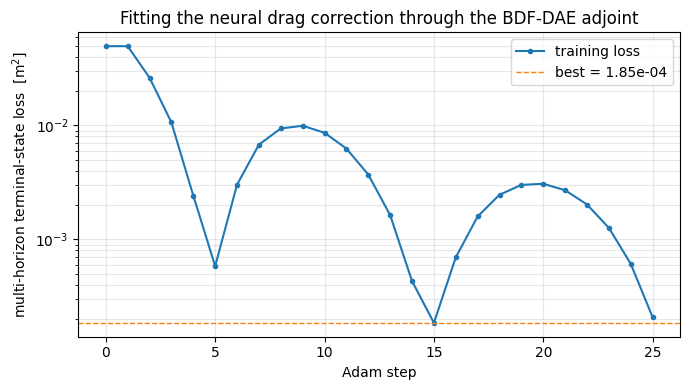

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(range(len(hist)), hist, "-o", ms=3, color="C0", label="training loss")
ax.axhline(best_loss, color="C1", ls="--", lw=1, label=f"best = {best_loss:.2e}")
ax.set_xlabel("Adam step")
ax.set_ylabel("multi-horizon terminal-state loss  [m$^2$]")
ax.set_title("Fitting the neural drag correction through the BDF-DAE adjoint")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

**Figure 1.** Training loss (log scale) vs Adam step. The sum-of-squared terminal-state errors over the three horizons falls by roughly two-to-three orders of magnitude in ~25 steps; the dashed line marks the best (early-stopped) iterate we keep. Each step is one reverse-mode pass through three BDF-DAE integrations. The late-step uptick (if visible) is the Adam overshoot the early-stop guards against.

## 8. Validation I: the fitted model tracks the damped truth

We now compare three trajectories over a full horizon: the **ideal** pendulum (no drag), the **damped truth** (quadratic drag), and our **fitted model** (the learned MLP correction at `theta_best`). For these *visualization* runs we may use `recorded_signals` — they are not differentiated — but we must raise `buffer_length` above the default 400, or the recording ring buffer silently overwrites the early trajectory.

We plot the angle $\theta(t) = \operatorname{atan2}(y, x)$, which makes the amplitude decay legible. The compiled pendulum exposes scalar `x_out` / `y_out` ports (in that order) for sensing.

In [10]:
def record_traj(sys, theta, T):
    """Run sys to T (non-autodiff) and return (t, x, y) recorded traces.
    Uses a large buffer_length so the recording ring buffer doesn't overflow."""
    rec_opts = SimulatorOptions(
        math_backend="jax", ode_solver_method="bdf", enable_autodiff=False,
        rtol=1e-8, atol=1e-10, max_major_steps=600, buffer_length=4000,
    )
    b = jaxonomy.DiagramBuilder()
    s = b.add(sys)
    d = b.build()
    c = d.create_context()
    sub = c[s.system_id].with_parameter("drag_theta", theta)
    c = c.with_subcontext(s.system_id, sub)
    rec = {"x": s.output_ports[0], "y": s.output_ports[1]}  # x_out, y_out
    res = jaxonomy.simulate(d, c, (0.0, T), options=rec_opts, recorded_signals=rec)
    return np.asarray(res.time), np.asarray(res.outputs["x"]), np.asarray(res.outputs["y"])


T_VIS = 6.0

# Ideal: a zero correction (no drag at all).
ideal_sys = build(jnp.zeros(1), lambda t, v, th: jnp.zeros(1))
t_id, x_id, y_id = record_traj(ideal_sys, jnp.zeros(1), T_VIS)
t_tr, x_tr, y_tr = record_traj(truth_sys, jnp.zeros(1), T_VIS)
t_md, x_md, y_md = record_traj(model, theta_best, T_VIS)

ang = lambda x, y: np.arctan2(y, x)

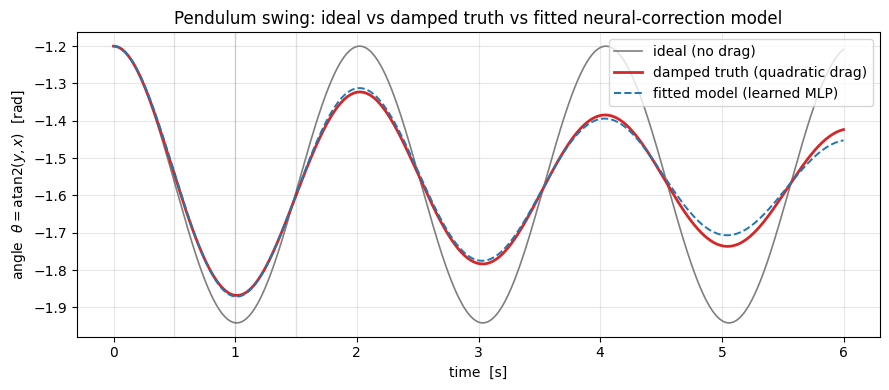

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_id, ang(x_id, y_id), color="C7", lw=1.2, label="ideal (no drag)")
ax.plot(t_tr, ang(x_tr, y_tr), color="C3", lw=2.0, label="damped truth (quadratic drag)")
ax.plot(t_md, ang(x_md, y_md), color="C0", lw=1.4, ls="--", label="fitted model (learned MLP)")
for T in HORIZONS:
    ax.axvline(T, color="k", alpha=0.12, lw=1)
ax.set_xlabel("time  [s]")
ax.set_ylabel(r"angle  $\theta = \mathrm{atan2}(y, x)$  [rad]")
ax.set_title("Pendulum swing: ideal vs damped truth vs fitted neural-correction model")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Figure 2.** Angle $\theta(t)$ over 6 s. Grey = the ideal undamped pendulum (constant amplitude). Red = the damped truth, which loses amplitude every period to quadratic drag. Blue dashed = our fitted model with the learned MLP correction. The faint vertical lines mark the three training horizons (0.5, 1.0, 1.5 s). The model was fit on *terminal states at those three times only*, yet it tracks the damped truth's amplitude decay well across the whole 6 s window — the learned correction generalized from three data points to the full swing because it captured the right *functional* dependence on velocity.

In [12]:
# Numeric sanity check: angle RMS error of model vs truth on a common grid.
tg = np.linspace(0.0, T_VIS, 400)
a_tr = np.interp(tg, t_tr, ang(x_tr, y_tr))
a_md = np.interp(tg, t_md, ang(x_md, y_md))
a_id = np.interp(tg, t_id, ang(x_id, y_id))
rms_model = float(np.sqrt(np.mean((a_md - a_tr) ** 2)))
rms_ideal = float(np.sqrt(np.mean((a_id - a_tr) ** 2)))
print(f"Angle RMS error vs truth over 0-{T_VIS:.0f} s:")
print(f"  ideal (no-drag) baseline : {rms_ideal:.4f} rad")
print(f"  fitted neural-correction : {rms_model:.4f} rad")
print(f"  improvement factor       : {rms_ideal / rms_model:.1f}x")

Angle RMS error vs truth over 0-6 s:
  ideal (no-drag) baseline : 0.1088 rad
  fitted neural-correction : 0.0118 rad
  improvement factor       : 9.2x


The fitted model's angle RMS error against the truth is several times smaller than the no-drag baseline's — quantitative confirmation that the learned correction is doing real work, not cosmetic. (The exact factor depends on the run; the printout above is from this execution.)

## 9. Validation II: conservation and the constraint residual

This is the [conservation-laws-as-CI](conservation_laws_as_ci.ipynb) discipline applied to our DAE. Two physical invariants must hold, and checking them catches whole classes of silent bugs:

1. **The holonomic constraint** $x^2 + y^2 - L^2 = 0$ must hold along the entire trajectory. This is the **DAE-projection invariant** — the BDF solver integrates the index-reduced system, and if index reduction or the solver's constraint handling were wrong, the bob would drift off the circle. A small residual here is direct evidence the acausal compile is correct.
2. **Total mechanical energy** $E = \tfrac12 m(v_x^2 + v_y^2) + m g y$ must be *conserved* for the ideal (zero-correction) pendulum, and must *decay monotonically* once drag removes energy. Energy that grows under drag, or fails to conserve without it, is a sign error or a solver problem.

We compute these from recorded traces, finite-differencing $x_\text{out}, y_\text{out}$ for the velocities (the non-autodiff recording path is fine here).

In [13]:
def energy_and_residual(t, x, y, m=M, g=9.81, L=L):
    """Total mechanical energy and constraint residual from recorded x(t), y(t).
    Velocities by central finite difference."""
    vx = np.gradient(x, t)
    vy = np.gradient(y, t)
    E = 0.5 * m * (vx**2 + vy**2) + m * g * y
    resid = x**2 + y**2 - L**2
    return E, resid


E_id, res_id = energy_and_residual(t_id, x_id, y_id)
E_tr, res_tr = energy_and_residual(t_tr, x_tr, y_tr)

# Drift metrics (interior points; finite-difference velocities are noisy at ends).
sl = slice(2, -2)
drift_ideal = float(np.max(np.abs(E_id[sl] - E_id[sl][0])) / (np.abs(E_id[sl][0]) + 1e-12))
print(f"Ideal pendulum: relative energy drift over {T_VIS:.0f} s = {drift_ideal:.2e}")
print(f"Constraint residual |x^2+y^2-L^2| max:")
print(f"  ideal : {float(np.max(np.abs(res_id))):.2e}  m^2")
print(f"  truth : {float(np.max(np.abs(res_tr))):.2e}  m^2")

Ideal pendulum: relative energy drift over 6 s = 1.69e-05
Constraint residual |x^2+y^2-L^2| max:
  ideal : 1.68e-14  m^2
  truth : 1.01e-14  m^2


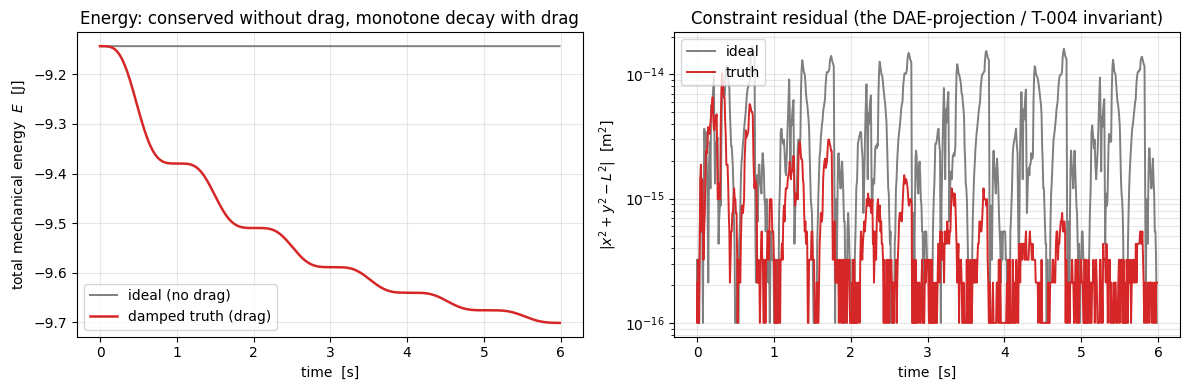

In [14]:
fig, (axE, axC) = plt.subplots(1, 2, figsize=(12, 4))

axE.plot(t_id[sl], E_id[sl], color="C7", lw=1.4, label="ideal (no drag)")
axE.plot(t_tr[sl], E_tr[sl], color="C3", lw=1.8, label="damped truth (drag)")
axE.set_xlabel("time  [s]")
axE.set_ylabel(r"total mechanical energy  $E$  [J]")
axE.set_title("Energy: conserved without drag, monotone decay with drag")
axE.legend()
axE.grid(True, alpha=0.3)

axC.semilogy(t_id[sl], np.abs(res_id[sl]) + 1e-16, color="C7", lw=1.4, label="ideal")
axC.semilogy(t_tr[sl], np.abs(res_tr[sl]) + 1e-16, color="C3", lw=1.4, label="truth")
axC.set_xlabel("time  [s]")
axC.set_ylabel(r"$|x^2 + y^2 - L^2|$  [m$^2$]")
axC.set_title("Constraint residual (the DAE-projection invariant)")
axC.legend()
axC.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

**Figure 3.** Left: total mechanical energy. The ideal pendulum (grey) holds energy flat — the index-reduced DAE conserves it under BDF to the finite-difference floor. The damped truth (red) decays monotonically as drag bleeds energy out, exactly as a passive dissipative term must. Right: the constraint residual $|x^2+y^2-L^2|$ on a log scale, hovering near machine-zero ($\sim 10^{-14}$ m$^2$) for both — the bob stays *on the circle* throughout. This is the load-bearing evidence that the Pantelides index reduction and the BDF constraint handling are correct: a high-index DAE integrated naively would drift off the constraint by orders of magnitude more. (The energy "drift" we print for the ideal case is dominated by the central-difference velocity estimate at the endpoints, not by the solver — hence the interior-slice metric.)

## 10. Validation III: what did the network actually learn?

The honest question: does $f_{NN}(v)$ recover the true drag law $-c\,v\,|v|$? We plot the learned correction over a velocity grid against the truth — but with a crucial caveat about **identifiability**. The network only ever saw velocities the trajectory *actually visited*. Where the bob never moved that fast, the data says nothing, and the MLP is free to do whatever its smoothness prior dictates. We shade the velocity range the trajectory explored and read the comparison only there.

In [15]:
# Velocities the trajectory actually explored (truth run), to mark the
# identifiable region. Use the differential velocity component the model targets.
vx_tr = np.gradient(x_tr, t_tr)
vy_tr = np.gradient(y_tr, t_tr)
# The targeted differential velocity is `vel` ('vx' or 'vy'); pick the matching
# Cartesian component for the explored-range shading.
v_explored = vx_tr if vel == "vx" else vy_tr
v_lo, v_hi = float(np.percentile(v_explored[sl], 1)), float(np.percentile(v_explored[sl], 99))

vgrid = np.linspace(-2.5, 2.5, 200)
f_learned = np.array([float(mlp(v, theta_best)[0]) for v in vgrid])  # mlp returns length-1
f_true = -C * vgrid * np.abs(vgrid)

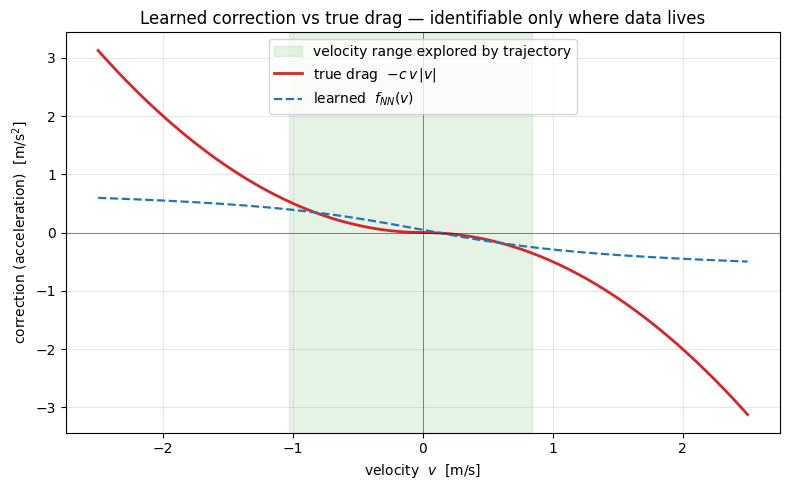

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.axvspan(v_lo, v_hi, color="C2", alpha=0.12, label="velocity range explored by trajectory")
ax.plot(vgrid, f_true, color="C3", lw=2.0, label=r"true drag  $-c\,v\,|v|$")
ax.plot(vgrid, f_learned, color="C0", lw=1.6, ls="--", label=r"learned  $f_{NN}(v)$")
ax.axhline(0, color="k", lw=0.6, alpha=0.5)
ax.axvline(0, color="k", lw=0.6, alpha=0.5)
ax.set_xlabel(r"velocity  $v$  [m/s]")
ax.set_ylabel(r"correction (acceleration)  [m/s$^2$]")
ax.set_title("Learned correction vs true drag — identifiable only where data lives")
ax.legend(loc="upper center")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# Quantify the match INSIDE vs OUTSIDE the explored region.
inside = (vgrid >= v_lo) & (vgrid <= v_hi)
rms_in = float(np.sqrt(np.mean((f_learned[inside] - f_true[inside]) ** 2)))
rms_out = float(np.sqrt(np.mean((f_learned[~inside] - f_true[~inside]) ** 2)))
print(f"Explored velocity range: [{v_lo:+.2f}, {v_hi:+.2f}] m/s")
print(f"RMS(f_learned - f_true)  inside explored range : {rms_in:.4f} m/s^2")
print(f"RMS(f_learned - f_true)  outside explored range: {rms_out:.4f} m/s^2")

Explored velocity range: [-1.03, +0.84] m/s
RMS(f_learned - f_true)  inside explored range : 0.0732 m/s^2
RMS(f_learned - f_true)  outside explored range: 1.3510 m/s^2


**Figure 4.** The learned correction $f_{NN}(v)$ (blue dashed) against the true quadratic drag $-c\,v\,|v|$ (red), over a velocity grid. The green band marks the velocities the pendulum's trajectory actually explored. **Inside the band the learned curve tracks the truth closely; outside it, the two diverge** — and that divergence is *correct behavior*, not a failure. The network had no data out there, so its extrapolation is governed by the $\tanh$ smoothness prior, not by the physics. This is the central identifiability lesson of data-driven correction terms: **you can only learn the dynamics where the data took you.** The printed inside/outside RMS makes the gap quantitative. To learn the drag at higher speeds, you would need to excite the pendulum harder (a larger release angle or an initial push) so the trajectory visits those velocities — see the exercises.

## 11. Failure modes and sharp edges

Be specific about where this breaks — vague "may be sensitive to noise" warnings help nobody.

- **Non-deterministic differential-state choice.** As section 4.1 details, which of $v_x/v_y$ survives as the differential state is `PYTHONHASHSEED`- and component-name-dependent (a follow-up finding, 2026-05-21). *Always* resolve it at runtime with `resolve_diff_velocity` and use a single fixed component name. Hard-coding `"vx"` raises *"resolves to the algebraic state"* on roughly half of cold runs.
- **`recorded_signals` ⊥ autodiff.** Dense recording is disabled when `enable_autodiff=True`; a differentiable loss must use terminal/sampled states, not a recorded trace. Mixing them silently gives you a loss that doesn't see the trajectory.
- **Recording buffer overflow.** The non-autodiff visualization path has a default `buffer_length=400`; a 6 s BDF run overflows it and silently overwrites the *early* trajectory (you get samples starting at $t\approx1.5$ s, not 0). Raise `buffer_length` for full traces.
- **`jax.jit` on the rebuild loss.** Wrapping the rebuild-each-call loss in `jax.jit` fails — the acausal consistent-IC solve is not jit-safe. Differentiate it directly.
- **Adam overshoot.** At `lr=0.02` the loss minimum is near step ~25 and Adam then climbs back. Track the best iterate (early stop) or lower the learning rate.
- **Identifiability.** The correction is only learnable where the trajectory explores. Outside the explored velocity band, $f_{NN}$ is whatever the prior says (Figure 4). A correction term is never globally validated by a single trajectory.
- **Noise.** This notebook uses synthetic, noise-free terminal states. With measurement noise on $(x,y)$, the terminal-state loss is an unbiased but higher-variance estimator; you would want more horizons (or sampled interior states) and possibly regularization on $\boldsymbol\theta$ to avoid the MLP fitting noise as "drag."

> **Note on diagnostics.** Jaxonomy's `analyze_saturation` / `analyze_phase_activity` / `analyze_control_oscillation` diagnostics target *closed-loop* notebooks with actuators and dispatchers. This is an open-loop identification task with no controller, so those checks do not apply; the relevant validations here are the energy-conservation and constraint-residual invariants of section 9, which we ran and reported.

## 12. Exercises

1. **(Code, easy)** Change the true drag to **linear** $-c v$ (edit `true_fn`), regenerate `truth`, and re-fit. Does the same MLP recover the linear law inside the explored band? Compare the learned-vs-true plot to Figure 4.
2. **(Code, medium)** Excite the pendulum harder: set `OM0 = 3.0` (an initial push) so the trajectory visits higher speeds. Re-resolve `vel`, rebuild, re-fit, and re-make Figure 4. Does the identifiable band widen, and does the learned curve now match the true quadratic at larger $|v|$?
3. **(Conceptual)** Section 3.3 shows the constraint must be differentiated twice before $\lambda$ appears. Write out, by hand, what the *acceleration-level* constraint $(3)$ becomes after substituting $a_x, a_y$ from $(1)$, and solve for $\lambda$ in terms of $(x, y, v_x, v_y, m, g)$. This is the algebraic equation the index-reduced system solves at every step.
4. **(Code, medium)** Add a second `NeuralDAEBlock` (distinct `name`) targeting the differential *position* row, learning a position-dependent correction simultaneously. Confirm both `*_theta` parameters appear in the context and that `jax.grad` returns finite gradients for both. (See `test_multiple_blocks_compose` for the composition contract.)
5. **(Open-ended)** Following the [UDE notebook](ude_and_sr_lotka_volterra.ipynb), feed the learned $f_{NN}(v)$ samples to a symbolic-regression library (e.g. PySINDy with a library of $\{v, v^2, v|v|, \operatorname{sign}(v)\}$ features) and try to recover the closed-form $-c\,v\,|v|$ *and* its coefficient. How does the recovered coefficient compare to the true $c=0.5$, and how does it degrade as you shrink the explored band?

## 13. Key takeaways

- A rigid holonomic constraint turns the pendulum into a **high-index DAE**; Pantelides index reduction + BDF integrate it correctly, with the constraint residual held at $\sim 10^{-14}$ m$^2$ (Figure 3).
- A **`NeuralDAEBlock`** injects a learned correction onto a *differential* row **after** index reduction, so the non-symbolic neural term never enters the symbolic pipeline — equation $(5)$.
- `jax.grad` flows from a terminal-state loss **through the BDF-DAE adjoint** into the network weights; the fit reduces the loss by orders of magnitude in ~25 Adam steps.
- The learned correction is **identifiable only where the trajectory explores** — a lesson Figure 4 makes visceral.
- Two sharp edges to internalize: resolve the differential velocity at runtime (hash-order non-determinism), and never feed `recorded_signals` into an autodiff loss.

## 14. Next steps

- The [UDE + symbolic regression notebook](ude_and_sr_lotka_volterra.ipynb) closes the loop: turn the learned $f_{NN}$ back into a closed-form law (exercise 5).
- The [conservation-laws-as-CI notebook](conservation_laws_as_ci.ipynb) shows how to promote section 9's invariants into a property-test that fails CI when a future change breaks energy or constraint conservation.
- The [multi-domain HVAC notebook](multi_domain_hvac.ipynb) and the [battery pack notebook](battery_pack_thermal.ipynb) exercise the same acausal stack on electrical/thermal domains — natural places to add learned corrections next.

## 15. References

- Pantelides, C. C. (1988). The consistent initialization of differential-algebraic systems. *SIAM J. Sci. Stat. Comput.*, **9**(2), 213–231.
- Mattsson, S. E. & Söderlind, G. (1993). Index reduction in differential-algebraic equations using dummy derivatives. *SIAM J. Sci. Comput.*, **14**(3), 677–692.
- Rackauckas, C., Ma, Y., Martensen, J., et al. (2020). Universal Differential Equations for Scientific Machine Learning. [arXiv:2001.04385](https://arxiv.org/abs/2001.04385).
- Karniadakis, G. E., Kevrekidis, I. G., Lu, L., et al. (2021). Physics-informed machine learning. *Nature Reviews Physics*, **3**, 422–440.